# Hawaii: SCHISM Demo

This notebook demonstrates the SCHISM ocean model workflow using
the same `coastal-calibration` API shown in the SFINCS demo.

SCHISM differs from SFINCS in a few key ways:

- **Prebuilt mesh**: SCHISM uses an unstructured triangular mesh
  that is prepared ahead of time (hgrid.gr3, vgrid.in, etc.)
- **MPI execution**: runs across multiple nodes using `mpiexec`
  and `pschism`
- **Atmospheric regridding**: NWM forcing is regridded onto the
  SCHISM mesh using ESMF, which requires a geogrid file

Despite these differences, the Python API is identical:
`CoastalCalibConfig` for configuration and `CoastalCalibRunner`
for execution. Only the `model_config` section changes.

## Setup

In [1]:
from __future__ import annotations

import os
from pathlib import Path

notebook_dir = Path.cwd()  # assumes notebook is run from docs/examples/notebooks/
os.chdir(notebook_dir.parent / "hawaii")

## 1. Build the run configuration

The configuration mirrors the SFINCS workflow. The main differences
are in `model_config`:

- `prebuilt_dir`: path to the pre-built SCHISM model files
- `geogrid_file`: WRF geogrid for ESMF atmospheric regridding
- `nodes`, `ntasks_per_node`, `nscribes`: MPI layout for `pschism`
- `include_noaa_gages`: auto-discover NOAA tide gauges in the domain

**Note**: the pre-built model directory (`./model`) and geogrid file
(`./geo_em_HI.nc`) are not included in the repository. Users must
place the correct files at these paths (or adjust the paths below).

In [2]:
from coastal_calibration import CoastalCalibConfig, CoastalCalibRunner, configure_logger

configure_logger(level="INFO")

run_config = CoastalCalibConfig.from_dict(
    {
        "model": "schism",
        "simulation": {
            "start_date": "2025-11-26",
            "duration_hours": 50,
            "coastal_domain": "hawaii",
            "meteo_source": "nwm_ana",
            "timestep_seconds": 300,  # 5-minute timestep
        },
        "boundary": {"source": "stofs"},
        "paths": {
            "work_dir": "./run",
            "raw_download_dir": "../downloads",
        },
        "download": {"enabled": True},
        "model_config": {
            "prebuilt_dir": "./model",  # pre-built mesh and config files
            "geogrid_file": "./geo_em_HI.nc",  # for ESMF atmospheric regridding
            "nodes": 1,  # number of compute nodes
            "ntasks_per_node": 4,  # MPI tasks per node
            "nscribes": 2,  # I/O server tasks
            "oversubscribe": True,
            "include_noaa_gages": True,
        },
    }
)

print(f"Work directory: {run_config.paths.work_dir}")
print(f"Prebuilt dir:   {run_config.model_config.prebuilt_dir}")
print(f"Domain:         {run_config.simulation.coastal_domain}")
print(f"Duration:       {run_config.simulation.duration_hours}h")

Work directory: docs/examples/hawaii/run
Prebuilt dir:   /Volumes/data/schism_models/hawaii
Domain:         hawaii
Duration:       50h


## 2. Run the pipeline

The pipeline executes 11 stages grouped into four phases:

1. **Download**: fetch NWM meteorological data and STOFS boundary data
2. **Forcing**: regrid atmospheric forcing onto the SCHISM mesh (ESMF),
   generate sflux files, process river discharge, and set up boundary
   conditions
3. **Model Prep**: update parameters, discover NOAA stations, partition
   the mesh for MPI
4. **Run & Validate**: execute `pschism` via `mpiexec`, post-process
   outputs, and generate comparison plots against NOAA observations

In [3]:
runner = CoastalCalibRunner(run_config)
result = runner.run()
if not result.success:
    raise RuntimeError(f"Pipeline failed at stage '{result.stages_failed}': {result.errors}")
print(result)

Cleaned generated files from                                                    
docs/examples/hawaii/run                  
Coastal Calibration Workflow                                                    
Start Time: 2026-03-30 15:51:53                                                 
----------------------------------------                                        
Stage: download                                                                 
Start Time: 2026-03-30 15:51:53                                                 
  Download input data (NWM, STOFS)                                              
  meteo/nwm_ana: 51/51 [OK]                                                     
  hydro/nwm: 204/204 [OK]                                                       
  coastal/stofs: 1/1 [OK]                                                       
  Total: 256/256 (failed: 0)                                                    
  Download complete — raw files stored in                         

WorkflowResult: SUCCESS
  Start:     2026-03-30 15:51:53
  End:       2026-03-30 18:35:01
  Duration:  2h 43m 8s
  Completed: download, schism_forcing_prep, schism_forcing, schism_sflux, schism_params, schism_obs, schism_boundary, schism_prep, schism_run, schism_postprocess, schism_plot


## 3. View results

The pipeline compares modeled water levels against NOAA CO-OPS
tide gauge observations at stations within the domain.

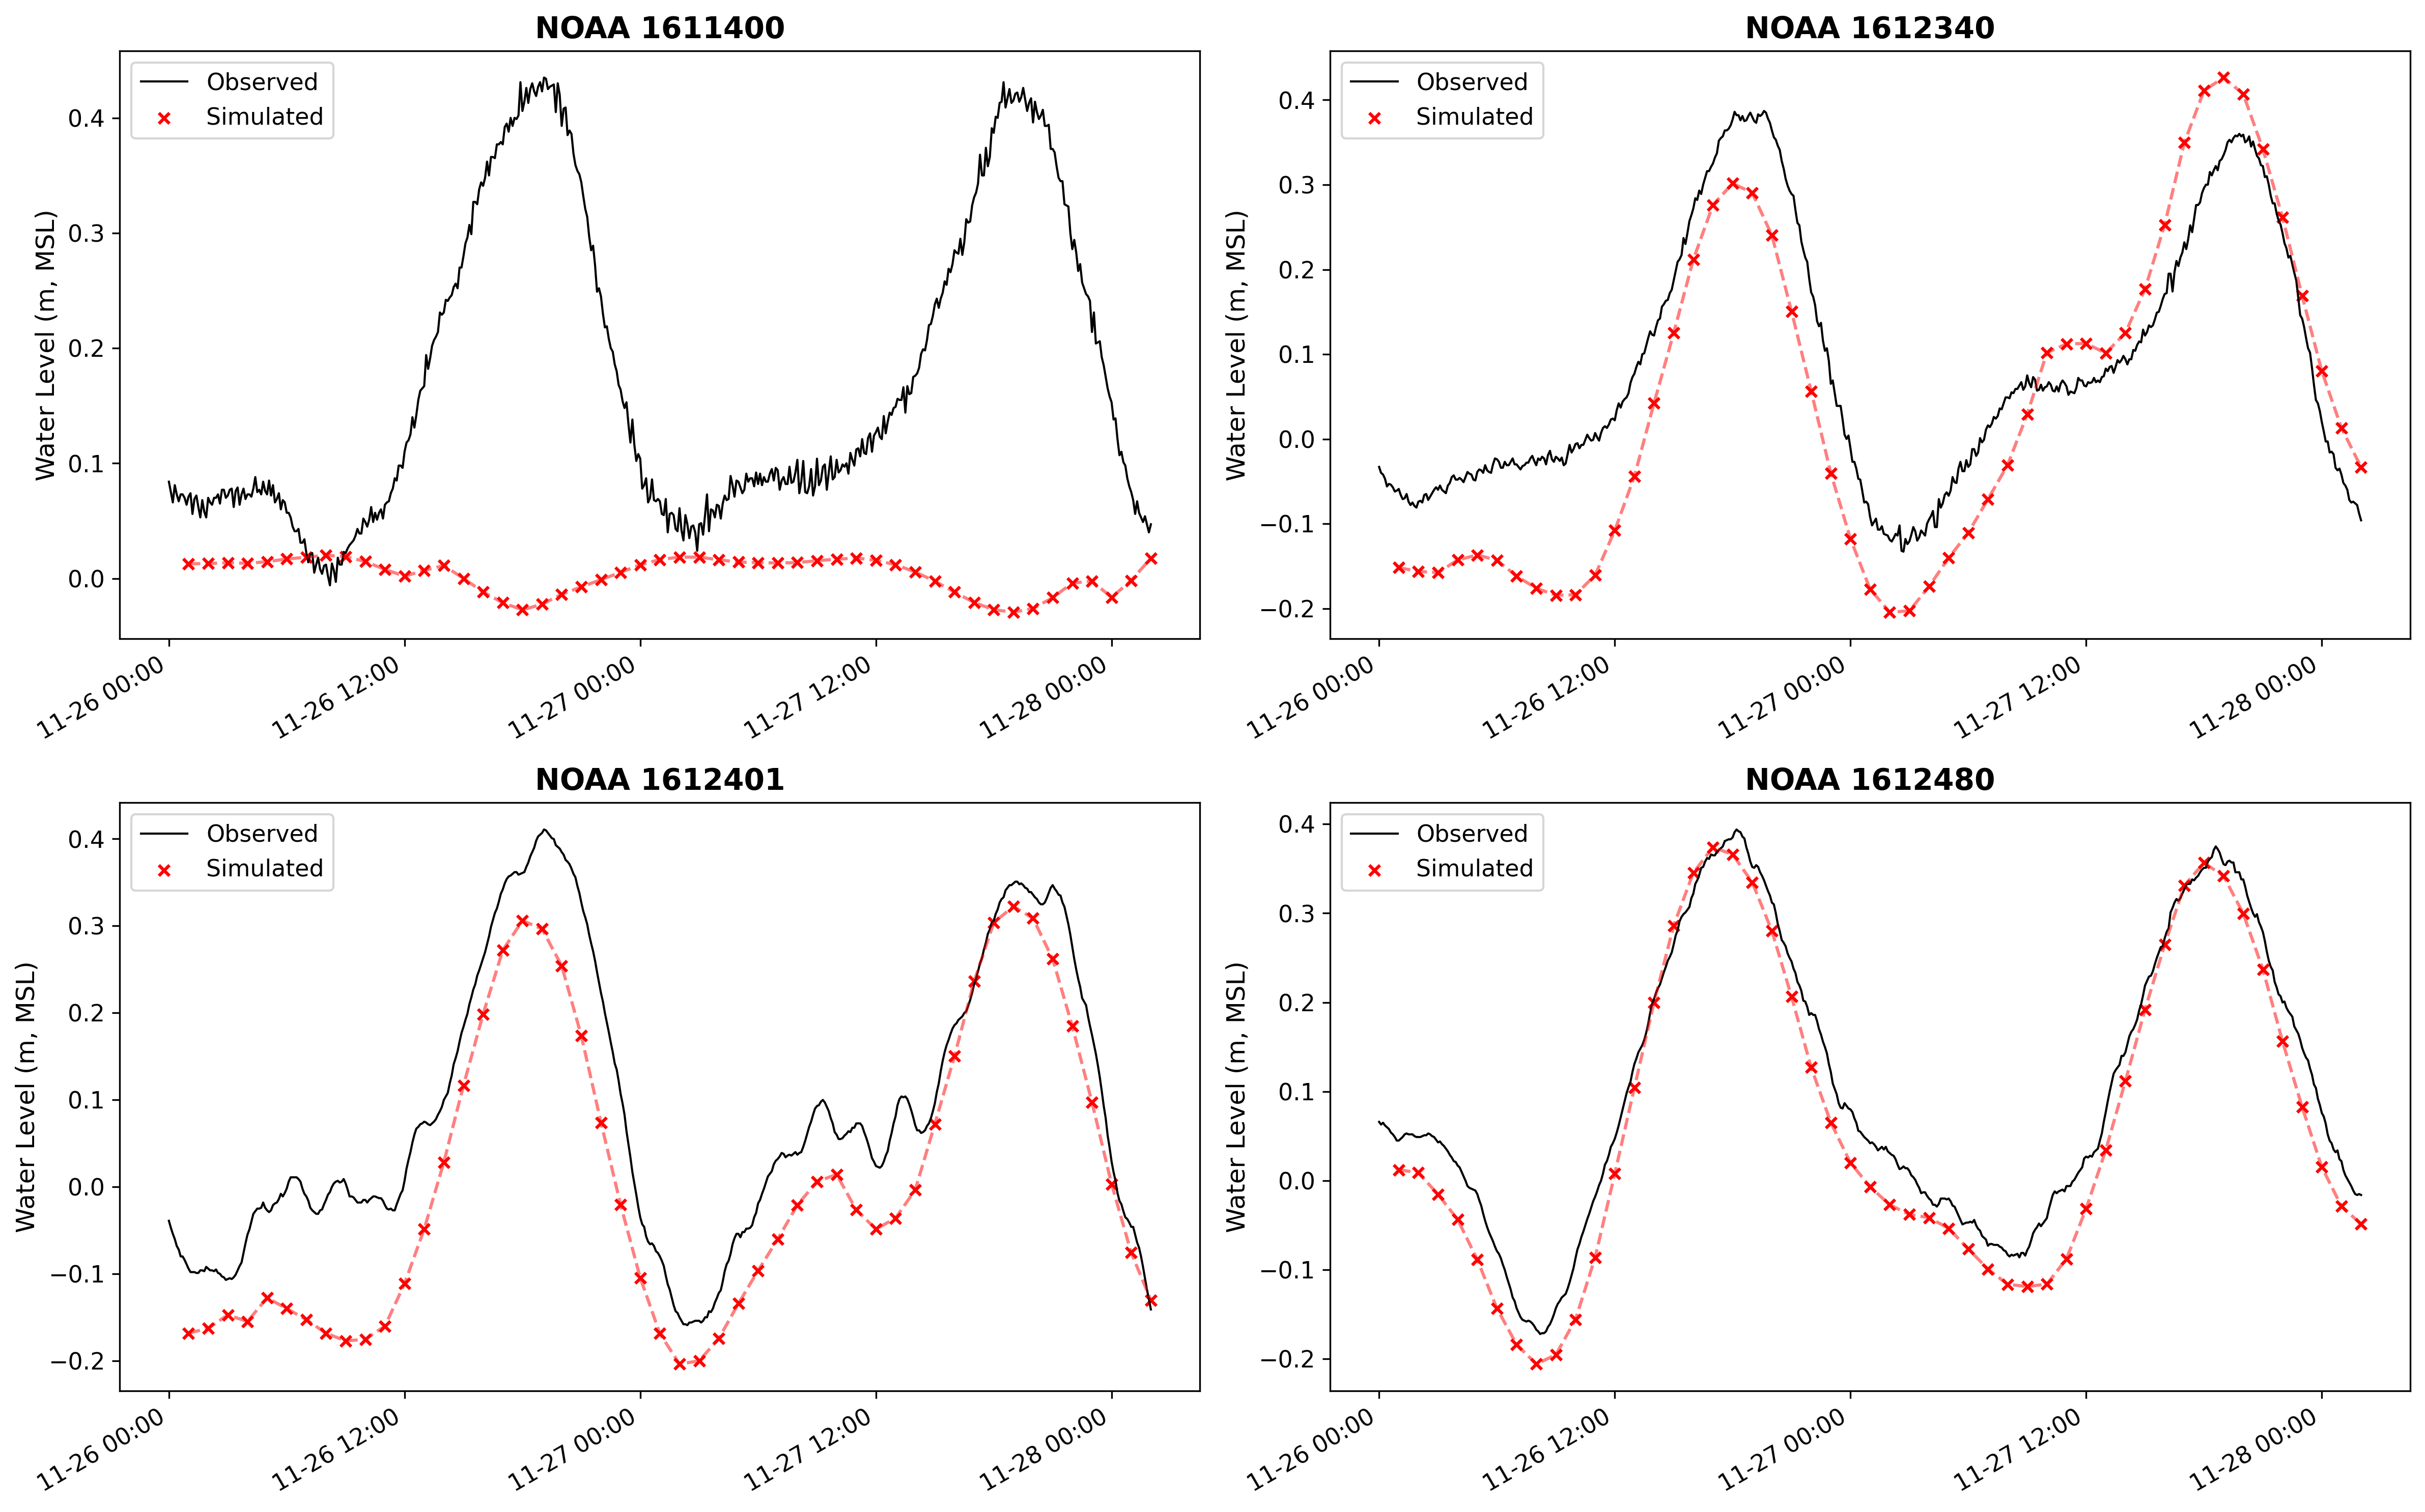

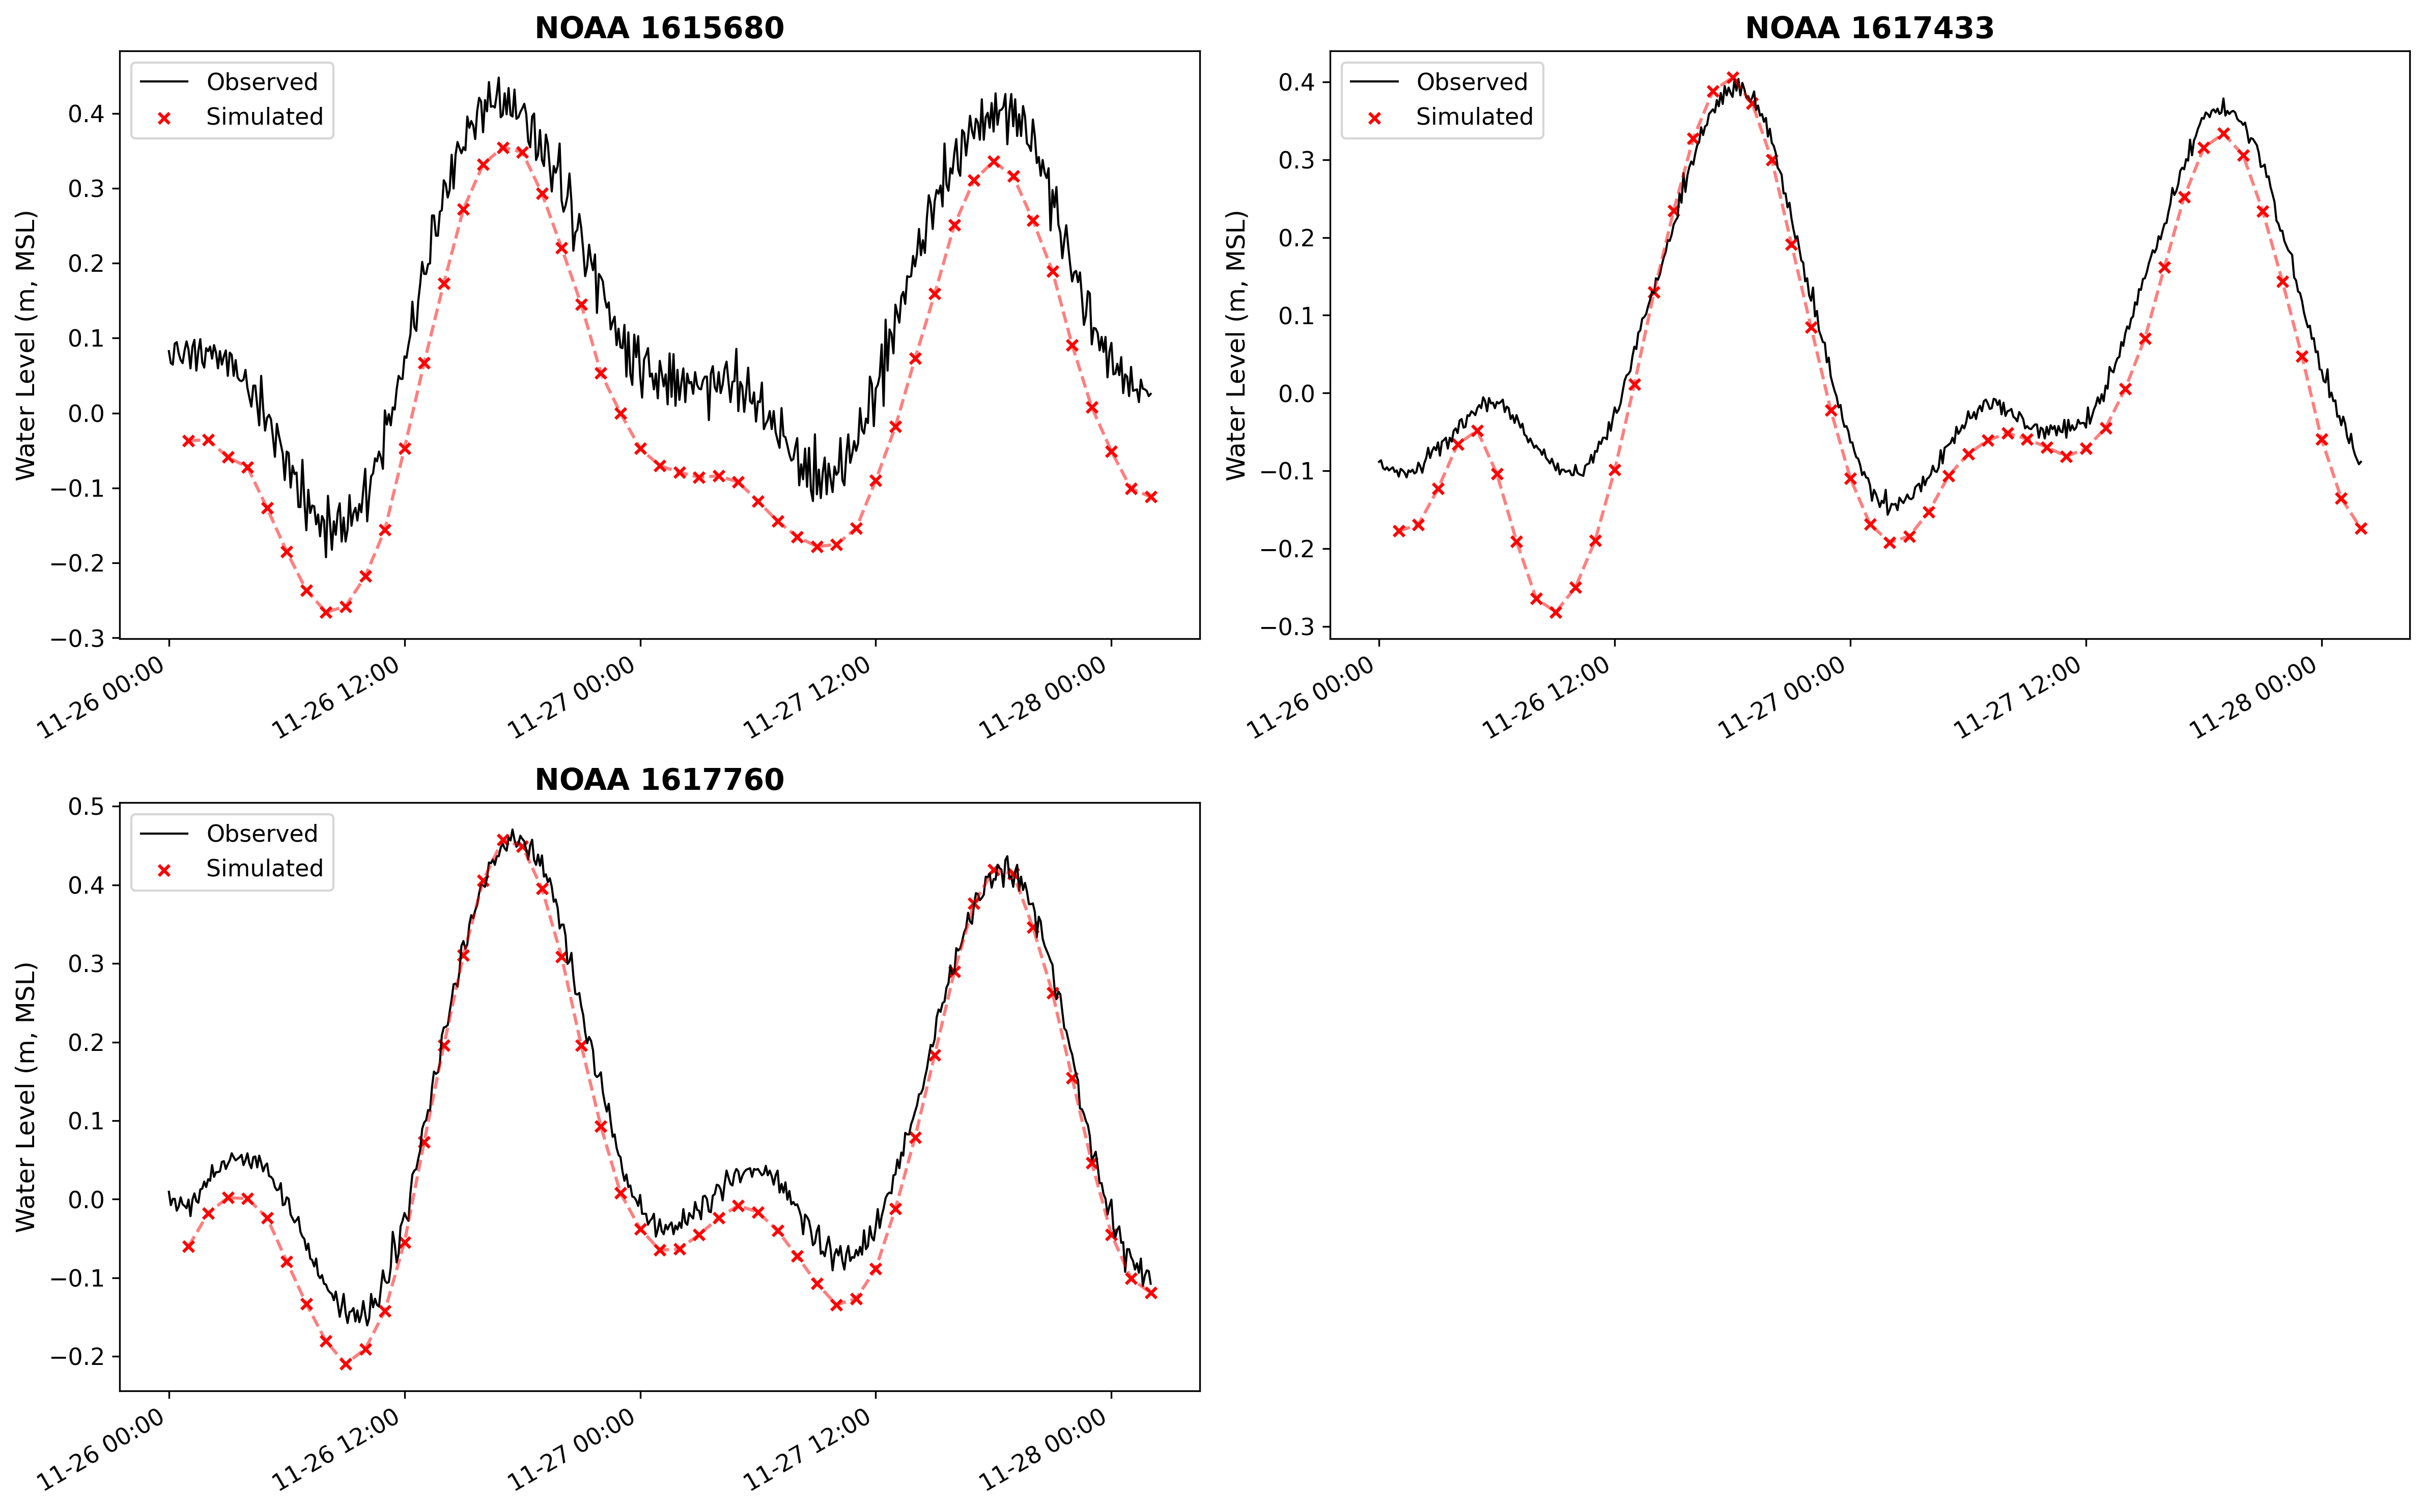

In [4]:
import shutil

from IPython.display import Image

figs = sorted(Path("run/figs").glob("stations_comparison_*.png"))
if not figs:
    print("No station comparison figures were generated; skipping thumbnail creation and display.")
else:
    shutil.copy2(figs[-1], "../images/hawaii_thumb.png")
    for png in figs:
        display(Image(filename=str(png), width=800))

## 4. Inspect outputs

In [5]:
outputs_dir = Path("run/outputs")
if outputs_dir.exists():
    all_outputs = sorted(outputs_dir.iterdir())
    for f in all_outputs[:20]:
        sz = f.stat().st_size
        label = f"{sz / 1e6:.1f} MB" if sz > 1e6 else f"{sz / 1e3:.1f} KB"
        print(f"  {f.name:<40s} {label}")
    if len(all_outputs) > 20:
        print(f"  ... and {len(all_outputs) - 20} more files")
else:
    print("No outputs directory found")

  JCG.out                                  1.6 MB
  coriolis.out                             117.6 MB
  fatal.error                              0.0 KB
  flux.out                                 0.0 KB
  global_to_local.prop                     27.3 MB
  local_to_global_000000                   190.4 MB
  local_to_global_000001                   189.8 MB
  maxdahv_000000                           60.9 MB
  maxdahv_000001                           60.3 MB
  maxelev_000000                           42.4 MB
  maxelev_000001                           42.0 MB
  mirror.out                               453.7 KB
  mirror.out.scribe                        1.2 KB
  nonfatal_000000                          1.8 KB
  nonfatal_000001                          80.3 KB
  out2d_1.nc                               141.2 MB
  out2d_10.nc                              141.2 MB
  out2d_11.nc                              141.2 MB
  out2d_12.nc                              141.2 MB
  out2d_13.nc               

## Running on HPC

The same configuration can be submitted to any HPC cluster using
a job scheduler. For example, with SLURM you can embed the config
directly in an `sbatch` script:

```bash
!/usr/bin/env bash
#SBATCH --job-name=coastal_schism
#SBATCH --partition=c5n-18xlarge
#SBATCH -N 2
#SBATCH --ntasks-per-node=18
#SBATCH --exclusive
#SBATCH --output=slurm-%j.out

CONFIG_FILE="/tmp/coastal_config_${SLURM_JOB_ID}.yaml"

cat > "${CONFIG_FILE}" <<'EOF'
model: schism

simulation:
  start_date: 2025-11-26
  duration_hours: 50
  coastal_domain: hawaii
  meteo_source: nwm_ana

boundary:
  source: stofs

model_config:
  include_noaa_gages: true
EOF

coastal-calibration run "${CONFIG_FILE}"
rm -f "${CONFIG_FILE}"
```

The same approach works with PBS, LSF, or any other scheduler.
The only requirement is that the `coastal-calibration` command
is available on the compute nodes.

## Summary

This notebook ran the full SCHISM pipeline for Hawaii using the
same API as SFINCS:

1. Configured `CoastalCalibConfig` with SCHISM-specific settings
   (MPI layout, geogrid for ESMF regridding)
2. Executed the 11-stage pipeline with `CoastalCalibRunner`
   (download, forcing, model prep, run, validate)
3. Compared modeled water levels against NOAA observations
4. Showed how the same config can be submitted to an HPC cluster
   via `sbatch` or any other job scheduler

The interface is identical to SFINCS. Only the `model_config`
section differs (MPI layout vs. OpenMP, geogrid for atmospheric
regridding, prebuilt mesh vs. automated creation).